# QAP — Búsqueda Tabú con comparación de operadores de vecindad

Implementación de **Búsqueda Tabú** para el *Problema de Asignación Cuadrática* (QAP),
comparando tres operadores de vecindad: **swap** (intercambio), **inserción** (shift) e
**inversión** (2-opt). Los tres comparten exactamente la misma mecánica tabú y el mismo
presupuesto de cómputo, de modo que las diferencias de desempeño reflejan el efecto del
operador y no de la implementación.

## Bloque 1 — Configuración

Definimos la ruta de las instancias, la semilla base (reproducibilidad), el número de
corridas independientes por configuración y la metadata de cada instancia: su tamaño `n`
y la mejor solución conocida (BKS), que usaremos para calcular el GAP.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Ruta a la carpeta con los archivos .dat de QAPLIB (ajustar si es necesario)
PATH = "/content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Instances"

In [3]:
import time
import pickle
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

# --- Reproducibilidad: la corrida r usa la semilla SEED_BASE + r ---
SEED_BASE = 42

# --- Número de ejecuciones independientes por (operador x instancia) ---
N_RUNS = 7

# --- Iteraciones de referencia: fijan el presupuesto de evaluaciones (ver Bloque 5) ---
REFERENCE_ITERATIONS = 1000

# --- Carpetas ---
INSTANCES_DIR = Path(PATH)
RESULTS_DIR = INSTANCES_DIR.parent / "Resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Metadata de las instancias: nombre -> (n, mejor solución conocida) ---
INSTANCES = {
    "bur26c":  {"size": 26,  "best_known": 5_426_795},
    "esc32h":  {"size": 32,  "best_known": 438},
    "esc64a":  {"size": 64,  "best_known": 116},
    "lipa60a": {"size": 60,  "best_known": 107_218},
    "tai80a":  {"size": 80,  "best_known": 13_499_184},
    "tai80b":  {"size": 80,  "best_known": 818_415_043},
}

print(f"Instancias        : {list(INSTANCES.keys())}")
print(f"Corridas/config.  : {N_RUNS}")
print(f"Semilla base      : {SEED_BASE}")
print(f"Resultados en     : {RESULTS_DIR}")

Instancias        : ['bur26c', 'esc32h', 'esc64a', 'lipa60a', 'tai80a', 'tai80b']
Corridas/config.  : 7
Semilla base      : 42
Resultados en     : /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados


In [4]:
print("¿Existe INSTANCES_DIR?:", INSTANCES_DIR.exists())

p = INSTANCES_DIR
while not p.exists() and p != p.parent:
    p = p.parent
print("Carpeta más profunda que SÍ existe:", p)
print("Contenido:")
for item in sorted(p.iterdir()):
    print("  ", item.name)

¿Existe INSTANCES_DIR?: True
Carpeta más profunda que SÍ existe: /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Instances
Contenido:
   bur26c.dat
   esc32h.dat
   esc64a.dat
   lipa60a.dat
   tai80a.dat
   tai80b.dat


## Bloque 2 — Lector de instancias QAPLIB

Cada archivo `.dat` contiene el tamaño `n` seguido de dos matrices de `n x n` (flujo y
distancia). Los números pueden venir repartidos en líneas irregulares, así que tomamos
**todos** los tokens numéricos en orden y los repartimos por conteo: el primero es `n`,
los siguientes `n*n` son la matriz de flujo y los últimos `n*n` la de distancia. Esto
hace el lector robusto frente a cualquier variación de formato.

In [5]:
@dataclass
class QAPInstance:
    name: str
    size: int           # n
    flow: np.ndarray    # matriz de flujo  (n x n)
    dist: np.ndarray    # matriz de distancia (n x n)
    best_known: int     # mejor solución conocida (BKS)


def read_qaplib(path: Path):
    """Lee un .dat de QAPLIB y devuelve (n, flow, dist) tokenizando todo el archivo."""
    numbers = [int(t) for t in Path(path).read_text().split()]
    n = numbers[0]
    rest = numbers[1:]

    expected = 2 * n * n
    if len(rest) < expected:
        raise ValueError(f"{path.name}: se esperaban {expected} valores, hay {len(rest)}.")

    flow = np.array(rest[:n * n],          dtype=np.int64).reshape(n, n)
    dist = np.array(rest[n * n:2 * n * n], dtype=np.int64).reshape(n, n)
    return n, flow, dist


def load_instance(name: str) -> QAPInstance:
    """Carga una instancia por nombre usando la metadata del Bloque 1."""
    meta = INSTANCES[name]
    n, flow, dist = read_qaplib(INSTANCES_DIR / f"{name}.dat")
    assert n == meta["size"], f"{name}: n leído ({n}) != n esperado ({meta['size']})"
    return QAPInstance(name, n, flow, dist, meta["best_known"])


# Prueba rápida
instance = load_instance("bur26c")
print(f"{instance.name}: n={instance.size}, "
      f"flow{instance.flow.shape}, dist{instance.dist.shape}, "
      f"BKS={instance.best_known:,}")

bur26c: n=26, flow(26, 26), dist(26, 26), BKS=5,426,795


## Bloque 3 — Función objetivo y validación

El costo de una permutación es `sum_{i,j} flow[i,j] * dist[perm[i], perm[j]]`. Lo
calculamos de forma vectorizada con NumPy. Como no disponemos de las permutaciones
óptimas (`.sln`) para todas las instancias, validamos la función objetivo por
**consistencia interna**: comparamos la versión vectorizada contra una versión ingenua
de doble bucle. Si coinciden en muchas permutaciones aleatorias, la implementación es
correcta.

In [6]:
def objective(perm, flow, dist):
    """Costo QAP de una permutación (vectorizado)."""
    dist_perm = dist[perm][:, perm]          # dist[perm[i], perm[j]] para todo i, j
    return int(np.sum(flow * dist_perm))


def objective_naive(perm, flow, dist):
    """Versión de referencia con doble bucle (lenta pero transparente)."""
    n = len(perm)
    total = 0
    for i in range(n):
        for j in range(n):
            total += flow[i, j] * dist[perm[i], perm[j]]
    return int(total)


# --- Validación cruzada: vectorizada vs. ingenua en todas las instancias ---
rng = np.random.default_rng(SEED_BASE)
all_ok = True
for name in INSTANCES:
    instance = load_instance(name)
    for _ in range(5):
        perm = rng.permutation(instance.size)
        if objective(perm, instance.flow, instance.dist) != \
           objective_naive(perm, instance.flow, instance.dist):
            all_ok = False
            print(f"✗ {name}: discrepancia")
    perm = rng.permutation(instance.size)
    cost = objective(perm, instance.flow, instance.dist)
    print(f"{name:8s}  aleatorio={cost:>15,}   BKS={instance.best_known:>15,}")

print("\n✓ Función objetivo validada (vectorizada == ingenua)" if all_ok
      else "\n✗ Hay discrepancias — revisar")

bur26c    aleatorio=      5,908,673   BKS=      5,426,795
esc32h    aleatorio=            690   BKS=            438
esc64a    aleatorio=            288   BKS=            116
lipa60a   aleatorio=        110,164   BKS=        107,218
tai80a    aleatorio=     15,696,536   BKS=     13,499,184
tai80b    aleatorio=  1,281,003,857   BKS=    818,415,043

✓ Función objetivo validada (vectorizada == ingenua)


## Bloque 4 — Operadores de vecindad (delta compilado con Numba)

Los tres operadores se implementan con la **misma técnica** para que la comparación de
tiempo sea justa: calcular el delta (variación del costo) de cada movimiento mediante una
función compilada con Numba (`njit`), que elimina el overhead del intérprete de Python.

- **swap**: intercambia las posiciones `r` y `s`. Delta directo en `O(n)`.
- **inserción**: mueve el elemento de `r` a `s` desplazando los intermedios; equivale a una
  cadena de intercambios adyacentes cuyos deltas acumulamos.
- **inversión (2-opt)**: invierte el segmento `[r, s]`; equivale a intercambiar los extremos
  hacia el centro, acumulando sus deltas.

Cada función `*_full_deltas` devuelve la matriz `n x n` con el delta de todos los
movimientos. La primera ejecución compila (tarda unos segundos una sola vez).

In [7]:
from numba import njit


@njit(cache=True)
def _swap_delta(perm, flow, dist, r, s):
    """Delta O(n) de intercambiar las posiciones r y s (caso general/asimétrico)."""
    n = perm.shape[0]
    a, b = perm[r], perm[s]
    delta = 0
    for k in range(n):
        if k == r or k == s:
            continue
        pk = perm[k]
        delta += (flow[r, k] * (dist[b, pk] - dist[a, pk])
                  + flow[s, k] * (dist[a, pk] - dist[b, pk])
                  + flow[k, r] * (dist[pk, b] - dist[pk, a])
                  + flow[k, s] * (dist[pk, a] - dist[pk, b]))
    delta += (flow[r, s] * (dist[b, a] - dist[a, b])
              + flow[s, r] * (dist[a, b] - dist[b, a])
              + flow[r, r] * (dist[b, b] - dist[a, a])
              + flow[s, s] * (dist[a, a] - dist[b, b]))
    return delta


@njit(cache=True)
def swap_full_deltas(perm, flow, dist):
    """Matriz n x n de deltas del swap. Simétrica, diagonal 0."""
    n = perm.shape[0]
    deltas = np.zeros((n, n), dtype=np.int64)
    for r in range(n - 1):
        for s in range(r + 1, n):
            d = _swap_delta(perm, flow, dist, r, s)
            deltas[r, s] = d
            deltas[s, r] = d
    return deltas


@njit(cache=True)
def insertion_full_deltas(perm, flow, dist):
    """Matriz n x n de deltas de inserción (mover r->s) vía swaps adyacentes acumulados."""
    n = perm.shape[0]
    deltas = np.zeros((n, n), dtype=np.int64)
    for r in range(n):
        # hacia la derecha: r -> r+1 -> ... -> n-1
        work = perm.copy()
        acc = 0
        for s in range(r, n - 1):
            acc += _swap_delta(work, flow, dist, s, s + 1)
            tmp = work[s]; work[s] = work[s + 1]; work[s + 1] = tmp
            deltas[r, s + 1] = acc
        # hacia la izquierda: r -> r-1 -> ... -> 0
        work = perm.copy()
        acc = 0
        for s in range(r, 0, -1):
            acc += _swap_delta(work, flow, dist, s, s - 1)
            tmp = work[s]; work[s] = work[s - 1]; work[s - 1] = tmp
            deltas[r, s - 1] = acc
    return deltas


@njit(cache=True)
def inversion_full_deltas(perm, flow, dist):
    """Matriz n x n de deltas de inversión (invertir segmento [r, s]) vía swaps de extremos."""
    n = perm.shape[0]
    deltas = np.zeros((n, n), dtype=np.int64)
    for r in range(n - 1):
        for s in range(r + 1, n):
            work = perm.copy()
            acc = 0
            i, j = r, s
            while i < j:
                acc += _swap_delta(work, flow, dist, i, j)
                tmp = work[i]; work[i] = work[j]; work[j] = tmp
                i += 1; j -= 1
            deltas[r, s] = acc
            deltas[s, r] = acc
    return deltas

In [8]:
# --- Aplicación del movimiento sobre una permutación ---
def apply_swap(perm, r, s):
    new = perm.copy()
    new[r], new[s] = new[s], new[r]
    return new


def apply_insertion(perm, r, s):
    value = perm[r]
    rest = np.delete(perm, r)
    return np.insert(rest, s, value)


def apply_inversion(perm, r, s):
    new = perm.copy()
    new[r:s + 1] = new[r:s + 1][::-1]
    return new


# --- Envoltorio de vecindario: (matriz de deltas, índices de los movimientos candidatos) ---
def swap_neighborhood(perm, flow, dist):
    n = len(perm)
    deltas = swap_full_deltas(perm, flow, dist)
    cand_r, cand_s = np.triu_indices(n, 1)          # pares r < s
    return deltas, (cand_r, cand_s)


def insertion_neighborhood(perm, flow, dist):
    n = len(perm)
    deltas = insertion_full_deltas(perm, flow, dist)
    rows, cols = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    mask = rows != cols                              # todos los pares r != s
    return deltas, (rows[mask], cols[mask])


def inversion_neighborhood(perm, flow, dist):
    n = len(perm)
    deltas = inversion_full_deltas(perm, flow, dist)
    cand_r, cand_s = np.triu_indices(n, 1)          # pares r < s
    return deltas, (cand_r, cand_s)


# Registro central: nombre -> (función de vecindario, función de aplicación)
OPERATORS = {
    "swap":      (swap_neighborhood,      apply_swap),
    "insertion": (insertion_neighborhood, apply_insertion),
    "inversion": (inversion_neighborhood, apply_inversion),
}

**Validación de los operadores.** Comprobamos que el delta de cada operador coincide
exactamente con la diferencia real de la función objetivo, en todos los movimientos del
vecindario.

In [9]:
instance = load_instance("bur26c")
rng = np.random.default_rng(SEED_BASE)
perm = rng.permutation(instance.size)
base_cost = objective(perm, instance.flow, instance.dist)

for op_name, (neighborhood, apply_move) in OPERATORS.items():
    deltas, (cand_r, cand_s) = neighborhood(perm, instance.flow, instance.dist)
    ok = True
    for r, s in zip(cand_r, cand_s):
        real = objective(apply_move(perm, int(r), int(s)), instance.flow, instance.dist) - base_cost
        if int(deltas[r, s]) != real:
            ok = False
            print(f"✗ {op_name}: discrepancia en ({r}, {s})")
            break
    print(f"{'✓' if ok else '✗'} {op_name}: delta validado contra la función objetivo")

✓ swap: delta validado contra la función objetivo
✓ insertion: delta validado contra la función objetivo
✓ inversion: delta validado contra la función objetivo


## Bloque 5 — Núcleo de la Búsqueda Tabú

El núcleo es **idéntico para los tres operadores**: solo cambia la función de vecindario
que recibe. En cada iteración evalúa todo el vecindario, elige el mejor movimiento no
prohibido por la lista tabú (salvo que cumpla el criterio de aspiración: mejorar la mejor
solución global), aplica el movimiento y actualiza la lista tabú.

El presupuesto se mide en **número de evaluaciones de la función objetivo**, no en
iteraciones. Esto es clave para la justicia de la comparación: como la inserción tiene un
vecindario casi del doble de tamaño, gastaría el doble de evaluaciones por iteración; al
fijar el presupuesto en evaluaciones, todos los operadores reciben el mismo esfuerzo de
cómputo. El historial se registra indexado por evaluaciones, para que las curvas de
convergencia sean comparables.

In [10]:
@dataclass
class TabuSearchResult:
    best_perm: np.ndarray
    best_cost: int
    history: list          # lista de (evaluaciones_acumuladas, mejor_costo)
    iterations: int
    elapsed_seconds: float


def initial_solution(size, rng):
    """Permutación inicial aleatoria."""
    return rng.permutation(size)


def eval_budget_for(size, reference_iterations=REFERENCE_ITERATIONS):
    """Presupuesto de evaluaciones = lo que el swap gastaría en 'reference_iterations'."""
    swap_neighborhood_size = size * (size - 1) // 2
    return reference_iterations * swap_neighborhood_size


def tabu_search(instance, neighborhood, apply_move, rng, eval_budget, tabu_tenure=None):
    """Búsqueda Tabú genérica para QAP, parametrizada por el operador de vecindad."""
    size, flow, dist = instance.size, instance.flow, instance.dist
    if tabu_tenure is None:
        tabu_tenure = max(1, size // 2)          # valor fijo razonable (sin tuning)

    perm = initial_solution(size, rng)
    cost = objective(perm, flow, dist)
    best_perm, best_cost = perm.copy(), cost

    # tabu_until[a, b] = iteración hasta la cual el par de elementos (a, b) está prohibido
    tabu_until = np.zeros((size, size), dtype=np.int64)

    evaluations = 0
    iteration = 0
    history = [(0, best_cost)]
    start = time.perf_counter()

    while evaluations < eval_budget:
        iteration += 1
        deltas, (cand_r, cand_s) = neighborhood(perm, flow, dist)
        evaluations += cand_r.shape[0]           # una evaluación por candidato del vecindario

        move_deltas = deltas[cand_r, cand_s]
        elem_a = perm[cand_r]
        elem_b = perm[cand_s]
        is_tabu = tabu_until[elem_a, elem_b] >= iteration
        improves_best = (cost + move_deltas) < best_cost   # criterio de aspiración
        allowed = (~is_tabu) | improves_best

        if not allowed.any():
            break

        candidate_costs = np.where(allowed, move_deltas, np.iinfo(np.int64).max)
        best_index = int(candidate_costs.argmin())
        r, s = int(cand_r[best_index]), int(cand_s[best_index])
        a, b = perm[r], perm[s]

        perm = apply_move(perm, r, s)
        cost += int(move_deltas[best_index])
        tabu_until[a, b] = iteration + tabu_tenure
        tabu_until[b, a] = iteration + tabu_tenure

        if cost < best_cost:
            best_cost, best_perm = cost, perm.copy()
        history.append((evaluations, best_cost))

    elapsed = time.perf_counter() - start
    return TabuSearchResult(best_perm, best_cost, history, iteration, elapsed)

## Bloque 6 — Experimentos (un operador a la vez)

`run_operator_experiment` ejecuta **un** operador sobre todas las instancias, `N_RUNS`
veces cada una, y guarda en disco:

- `resultados_<operador>.csv`: tabla con costo, GAP, iteraciones y tiempo por corrida.
- `historiales_<operador>.pkl`: historiales de convergencia (para los gráficos del informe).

Diseñado para correrse **por separado**: ejecutas el operador rápido (swap), guardas;
luego inserción; y por último inversión (el más lento). Si una sesión se corta, no pierdes
lo ya calculado.

In [11]:
def run_operator_experiment(operator_name, reference_iterations=REFERENCE_ITERATIONS, verbose=True):
    """Ejecuta un operador sobre todas las instancias (N_RUNS c/u) y guarda los resultados."""
    neighborhood, apply_move = OPERATORS[operator_name]
    rows = []
    histories = {}

    print(f"=== Operador: {operator_name} ===")
    for inst_name in INSTANCES:
        instance = load_instance(inst_name)
        budget = eval_budget_for(instance.size, reference_iterations)
        gaps = []
        for run in range(N_RUNS):
            rng = np.random.default_rng(SEED_BASE + run)
            result = tabu_search(instance, neighborhood, apply_move, rng, budget)
            gap = (result.best_cost - instance.best_known) / instance.best_known * 100
            gaps.append(gap)
            rows.append({
                "operator": operator_name,
                "instance": inst_name,
                "run": run,
                "best_cost": result.best_cost,
                "gap_percent": gap,
                "iterations": result.iterations,
                "elapsed_seconds": result.elapsed_seconds,
            })
            histories[(inst_name, run)] = result.history
        if verbose:
            print(f"  {inst_name:8s}  GAP min={min(gaps):.3f}%  prom={np.mean(gaps):.3f}%  "
                  f"std={np.std(gaps):.3f}  t/corrida={rows[-1]['elapsed_seconds']:.2f}s")

    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / f"resultados_{operator_name}.csv", index=False)
    with open(RESULTS_DIR / f"historiales_{operator_name}.pkl", "wb") as f:
        pickle.dump(histories, f)
    print(f"✓ Guardado en {RESULTS_DIR}")
    return df, histories

### 6.1 — Ejecutar SWAP

In [12]:
df_swap, hist_swap = run_operator_experiment("swap")
df_swap

=== Operador: swap ===
  bur26c    GAP min=0.037%  prom=0.272%  std=0.187  t/corrida=0.16s
  esc32h    GAP min=0.457%  prom=1.892%  std=1.733  t/corrida=0.23s
  esc64a    GAP min=0.000%  prom=1.232%  std=1.518  t/corrida=1.76s
  lipa60a   GAP min=0.764%  prom=0.799%  std=0.020  t/corrida=0.91s
  tai80a    GAP min=1.763%  prom=2.126%  std=0.190  t/corrida=1.94s
  tai80b    GAP min=3.870%  prom=6.150%  std=1.660  t/corrida=1.95s
✓ Guardado en /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados


,operator,instance,run,best_cost,gap_percent,iterations,elapsed_seconds
0,swap,bur26c,0,5458390,0.582204,1000,0.163184
1,swap,bur26c,1,5451201,0.449731,1000,0.165755
2,swap,bur26c,2,5430470,0.067720,1000,0.160511
3,swap,bur26c,3,5446794,0.368523,1000,0.153478
4,swap,bur26c,4,5428789,0.036744,1000,0.147783
5,swap,bur26c,5,5436648,0.181562,1000,0.149204
6,swap,bur26c,6,5438574,0.217053,1000,0.159251
7,swap,esc32h,0,444,1.369863,1000,0.216748
8,swap,esc32h,1,458,4.566210,1000,0.218861
9,swap,esc32h,2,458,4.566210,1000,0.221068


### 6.2 — Ejecutar INSERCIÓN

In [13]:
df_insertion, hist_insertion = run_operator_experiment("insertion")
df_insertion

=== Operador: insertion ===
  bur26c    GAP min=0.482%  prom=1.400%  std=0.596  t/corrida=0.14s
  esc32h    GAP min=6.849%  prom=15.917%  std=5.022  t/corrida=0.21s
  esc64a    GAP min=13.793%  prom=19.704%  std=6.826  t/corrida=1.68s
  lipa60a   GAP min=1.361%  prom=1.419%  std=0.035  t/corrida=0.89s
  tai80a    GAP min=6.918%  prom=7.448%  std=0.425  t/corrida=1.88s
  tai80b    GAP min=18.893%  prom=23.146%  std=2.642  t/corrida=1.96s
✓ Guardado en /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados


,operator,instance,run,best_cost,gap_percent,iterations,elapsed_seconds
0,insertion,bur26c,0,5493298,1.225456,500,0.144480
1,insertion,bur26c,1,5469762,0.791756,500,0.139854
2,insertion,bur26c,2,5513605,1.599655,500,0.145199
3,insertion,bur26c,3,5500884,1.365244,500,0.130921
4,insertion,bur26c,4,5538674,2.061604,500,0.132874
5,insertion,bur26c,5,5452958,0.482108,500,0.146540
6,insertion,bur26c,6,5550166,2.273368,500,0.137333
7,insertion,esc32h,0,522,19.178082,500,0.201591
8,insertion,esc32h,1,544,24.200913,500,0.200431
9,insertion,esc32h,2,468,6.849315,500,0.190725


### 6.3 — Ejecutar INVERSIÓN

Nota: la inversión es el operador más lento (su delta acumula varios intercambios por
movimiento), así que las instancias `tai80` tomarán más tiempo. Por eso conviene correrla
por separado.

In [14]:
df_inversion, hist_inversion = run_operator_experiment("inversion")
df_inversion

=== Operador: inversion ===
  bur26c    GAP min=0.482%  prom=0.950%  std=0.445  t/corrida=0.43s
  esc32h    GAP min=1.826%  prom=7.763%  std=3.694  t/corrida=0.84s
  esc64a    GAP min=0.000%  prom=4.926%  std=6.143  t/corrida=13.76s
  lipa60a   GAP min=1.214%  prom=1.313%  std=0.044  t/corrida=9.69s
  tai80a    GAP min=6.333%  prom=6.573%  std=0.148  t/corrida=27.57s
  tai80b    GAP min=15.532%  prom=18.314%  std=1.338  t/corrida=26.69s
✓ Guardado en /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados


,operator,instance,run,best_cost,gap_percent,iterations,elapsed_seconds
0,inversion,bur26c,0,5481310,1.004552,1000,0.472397
1,inversion,bur26c,1,5452979,0.482495,1000,0.428337
2,inversion,bur26c,2,5459573,0.604003,1000,0.452257
3,inversion,bur26c,3,5528352,1.871399,1000,0.427831
4,inversion,bur26c,4,5459305,0.599064,1000,0.444991
5,inversion,bur26c,5,5492677,1.214013,1000,0.420215
6,inversion,bur26c,6,5474299,0.875360,1000,0.433806
7,inversion,esc32h,0,480,9.589041,1000,1.561745
8,inversion,esc32h,1,472,7.762557,1000,1.372038
9,inversion,esc32h,2,476,8.675799,1000,1.362735


## Bloque 7 — Consolidación de resultados

Carga los CSV guardados de los tres operadores y construye la tabla resumen con las
métricas pedidas: mejor GAP, GAP promedio, desviación estándar y tiempo promedio, por
instancia y operador.

In [15]:
frames = []
for op_name in OPERATORS:
    path = RESULTS_DIR / f"resultados_{op_name}.csv"
    if path.exists():
        frames.append(pd.read_csv(path))

results = pd.concat(frames, ignore_index=True)

summary = (results
           .groupby(["instance", "operator"])
           .agg(gap_min=("gap_percent", "min"),
                gap_mean=("gap_percent", "mean"),
                gap_std=("gap_percent", "std"),
                time_mean=("elapsed_seconds", "mean"))
           .round(3))
summary

gap_min  gap_mean  gap_std  time_mean
instance operator                                        
bur26c   insertion    0.482     1.400    0.643      0.140
         inversion    0.482     0.950    0.481      0.440
         swap         0.037     0.272    0.202      0.157
esc32h   insertion    6.849    15.917    5.425      0.200
         inversion    1.826     7.763    3.989      1.201
         swap         0.457     1.892    1.872      0.221
esc64a   insertion   13.793    19.704    7.373      1.191
         inversion    0.000     4.926    6.635     12.250
         swap         0.000     1.232    1.640      1.379
lipa60a  insertion    1.361     1.419    0.038      0.984
         inversion    1.214     1.313    0.047      9.076
         swap         0.764     0.799    0.021      0.939
tai80a   insertion    6.918     7.448    0.459      2.141
         inversion    6.333     6.573    0.159     28.038
         swap         1.763     2.126    0.205      2.280
tai80b   insertion   18.893    23.146    2.854      2.177
         inversion   15.532    18.314    1.446     27.462
         swap         3.870     6.150    1.793      2.205

## Bloque 8 — Curvas de convergencia (reproducible desde disco)

Genera una figura de convergencia por instancia (GAP vs. evaluaciones de la función objetivo), comparando los tres operadores, y las guarda en la carpeta de resultados. Los historiales se cargan desde los archivos .pkl guardados, de modo que el bloque es reproducible sin re-ejecutar el experimento ni depender de variables en memoria. Para cada operador se muestra la corrida MEDIANA (representativa según el GAP final), y una banda sombreada entre la mejor y la peor corrida para visualizar la variabilidad entre ejecuciones. El eje X son las evaluaciones de la función objetivo (no iteraciones), lo que hace las curvas de los tres operadores directamente comparables bajo el presupuesto justo.

✓ Guardada: convergencia_bur26c.png


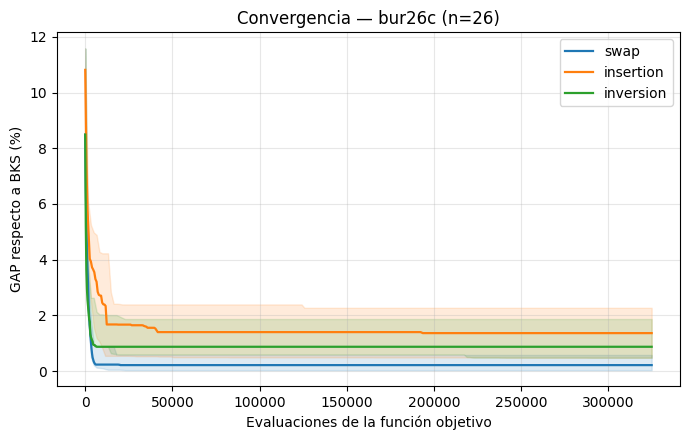

✓ Guardada: convergencia_esc32h.png


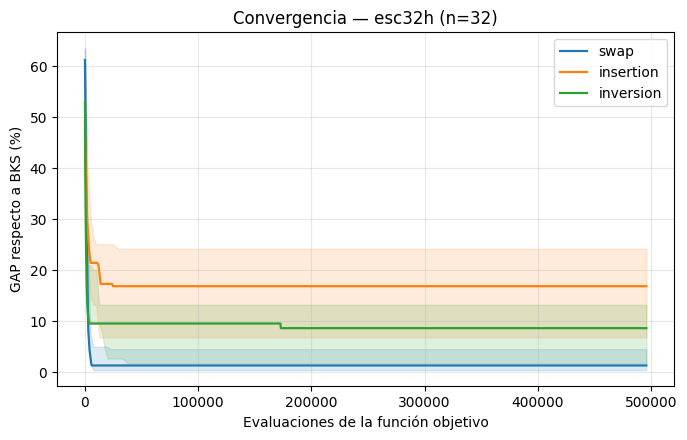

✓ Guardada: convergencia_esc64a.png


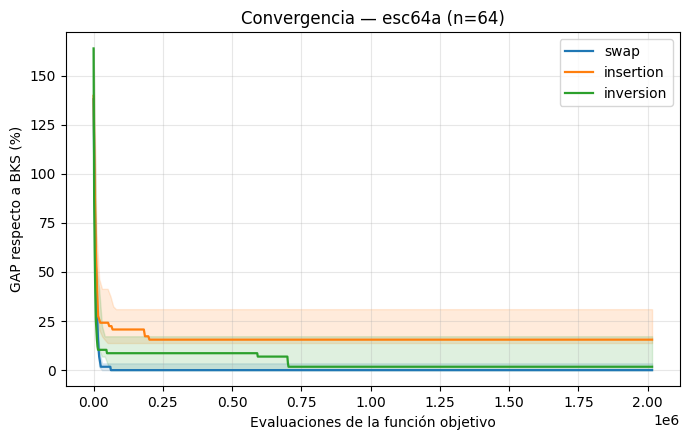

✓ Guardada: convergencia_lipa60a.png


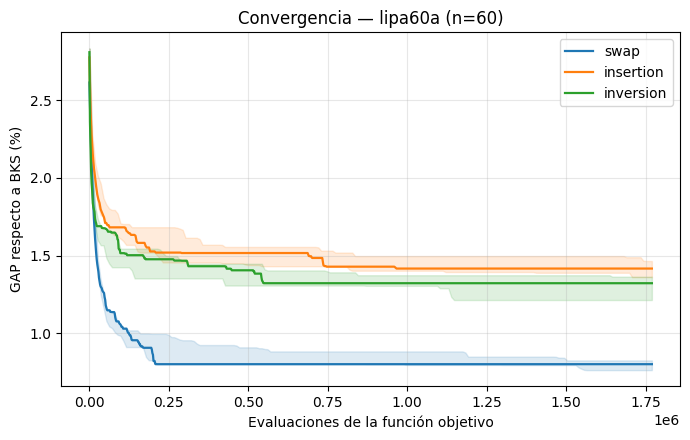

✓ Guardada: convergencia_tai80a.png


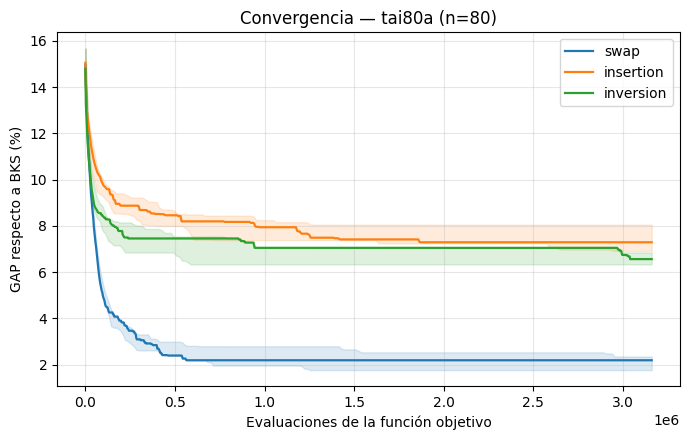

✓ Guardada: convergencia_tai80b.png


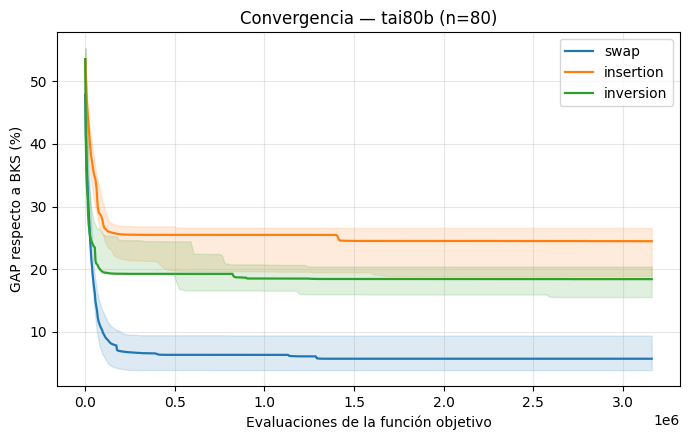


✓ 6 figuras guardadas en /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados/Figuras


In [18]:
import matplotlib.pyplot as plt

# --- Cargar historiales desde disco (reproducible, no depende de memoria) ---
def load_histories():
    histories = {}
    for op_name in OPERATORS:
        path = RESULTS_DIR / f"historiales_{op_name}.pkl"
        if path.exists():
            with open(path, "rb") as f:
                histories[op_name] = pickle.load(f)
    return histories

HISTORIES = load_histories()

# Carpeta para las figuras
FIGURES_DIR = RESULTS_DIR / "Figuras"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"swap": "#1f77b4", "insertion": "#ff7f0e", "inversion": "#2ca02c"}


def gap_curve(history, best_known):
    """Convierte un historial [(evals, costo)] en (evals, gap%)."""
    evals, costs = zip(*history)
    gap = (np.array(costs) - best_known) / best_known * 100
    return np.array(evals), gap


def plot_instance_convergence(inst_name, save=True):
    instance = load_instance(inst_name)
    plt.figure(figsize=(7, 4.5))

    for op_name in OPERATORS:
        runs = [HISTORIES[op_name][(inst_name, r)] for r in range(N_RUNS)]
        # corrida mediana según el GAP final
        final_gaps = [(r[-1][1] - instance.best_known) / instance.best_known * 100 for r in runs]
        median_idx = int(np.argsort(final_gaps)[len(final_gaps) // 2])

        # banda mejor-peor: interpolamos todas las curvas a una grilla común de evaluaciones
        max_evals = max(r[-1][0] for r in runs)
        grid = np.linspace(0, max_evals, 200)
        interp = []
        for r in runs:
            ev, gp = gap_curve(r, instance.best_known)
            interp.append(np.interp(grid, ev, gp))
        interp = np.array(interp)

        ev_med, gp_med = gap_curve(runs[median_idx], instance.best_known)
        c = COLORS[op_name]
        plt.fill_between(grid, interp.min(axis=0), interp.max(axis=0), color=c, alpha=0.15)
        plt.plot(ev_med, gp_med, color=c, lw=1.6, label=op_name)

    plt.title(f"Convergencia — {inst_name} (n={instance.size})")
    plt.xlabel("Evaluaciones de la función objetivo")
    plt.ylabel("GAP respecto a BKS (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save:
        out = FIGURES_DIR / f"convergencia_{inst_name}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"✓ Guardada: {out.name}")
    plt.show()


# --- Generar y guardar las 6 figuras ---
for inst_name in INSTANCES:
    plot_instance_convergence(inst_name)

print(f"\n✓ {len(INSTANCES)} figuras guardadas en {FIGURES_DIR}")

## Bloque 9 — Significancia estadística (Friedman + Nemenyi)

**¿Las diferencias entre operadores son significativas?** Las estadísticas descriptivas muestran que el swap obtiene mejores GAP, pero para afirmar que la diferencia es real y no producto del azar usamos pruebas no paramétricas, el estándar en la comparación de metaheurísticas (no asumen normalidad). El test de Friedman compara los tres operadores sobre todas las instancias de forma conjunta: rankea los operadores en cada instancia (1 = mejor GAP promedio) y evalúa si los rankings difieren significativamente. Si el p-valor es menor a 0.05, rechazamos la hipótesis de que los tres operadores son equivalentes. Como complemento, el post-hoc de Nemenyi indica qué pares de operadores difieren entre sí. Reportamos también el ranking promedio de cada operador, que resume su desempeño relativo global.

In [17]:
from scipy.stats import friedmanchisquare, rankdata

# --- Matriz instancias x operadores con el GAP promedio (de la tabla summary) ---
operators = list(OPERATORS.keys())
instance_names = list(INSTANCES.keys())

gap_matrix = np.array([
    [results[(results.instance == inst) & (results.operator == op)]["gap_percent"].mean()
     for op in operators]
    for inst in instance_names
])

print("GAP promedio (filas=instancias, columnas=operadores):")
print(pd.DataFrame(gap_matrix, index=instance_names, columns=operators).round(3))

# --- Test de Friedman (menor GAP = mejor) ---
stat, p_value = friedmanchisquare(*[gap_matrix[:, j] for j in range(len(operators))])
print(f"\nFriedman: estadístico = {stat:.4f},  p-valor = {p_value:.5f}")
print("=> Diferencias SIGNIFICATIVAS (p < 0.05)" if p_value < 0.05
      else "=> No se detectan diferencias significativas")

# --- Ranking promedio (1 = mejor en cada instancia) ---
ranks = np.array([rankdata(row) for row in gap_matrix])   # rankea por fila (menor GAP -> rank 1)
avg_ranks = ranks.mean(axis=0)
print("\nRanking promedio (menor es mejor):")
for op, r in sorted(zip(operators, avg_ranks), key=lambda x: x[1]):
    print(f"  {op:10s}  {r:.3f}")

# --- Post-hoc de Nemenyi (qué pares difieren) ---
try:
    import scikit_posthocs as sp
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-posthocs"])
    import scikit_posthocs as sp

nemenyi = sp.posthoc_nemenyi_friedman(gap_matrix)
nemenyi.index = operators
nemenyi.columns = operators
print("\nPost-hoc de Nemenyi (p-valores por par):")
print(nemenyi.round(4))

GAP promedio (filas=instancias, columnas=operadores):
          swap  insertion  inversion
bur26c   0.272      1.400      0.950
esc32h   1.892     15.917      7.763
esc64a   1.232     19.704      4.926
lipa60a  0.799      1.419      1.313
tai80a   2.126      7.448      6.573
tai80b   6.150     23.146     18.314

Friedman: estadístico = 12.0000,  p-valor = 0.00248
=> Diferencias SIGNIFICATIVAS (p < 0.05)

Ranking promedio (menor es mejor):
  swap        1.000
  inversion   2.000
  insertion   3.000

Post-hoc de Nemenyi (p-valores por par):
             swap  insertion  inversion
swap       1.0000     0.0015     0.1932
insertion  0.0015     1.0000     0.1932
inversion  0.1932     0.1932     1.0000


## Bloque 10 — Distribución del GAP final (boxplots)

Mientras las curvas de convergencia muestran la evolución, los boxplots resumen la distribución del GAP final de las 7 corridas de cada operador: mediana (línea central), rango intercuartílico (caja), bigotes y valores atípicos. Esto visualiza directamente la consistencia de cada operador (cajas angostas = resultados estables; cajas anchas o con outliers = resultados erráticos), complementando la desviación estándar de la tabla resumen. Usamos un panel por instancia, cada uno con su propia escala, porque los rangos de GAP difieren mucho entre instancias. Los datos provienen de los CSV guardados, de modo que el bloque es reproducible sin re-ejecutar el experimento. La figura se guarda en la carpeta de resultados.

/tmp/ipykernel_3845/721224913.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=operators, patch_artist=True, widths=0.6,
/tmp/ipykernel_3845/721224913.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=operators, patch_artist=True, widths=0.6,
/tmp/ipykernel_3845/721224913.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=operators, patch_artist=True, widths=0.6,
/tmp/ipykernel_3845/721224913.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support

✓ Guardada: /content/drive/MyDrive/Laboratorios Optimización 2026/Tarea 2 QAP/Resultados/Figuras/boxplots_gap.png


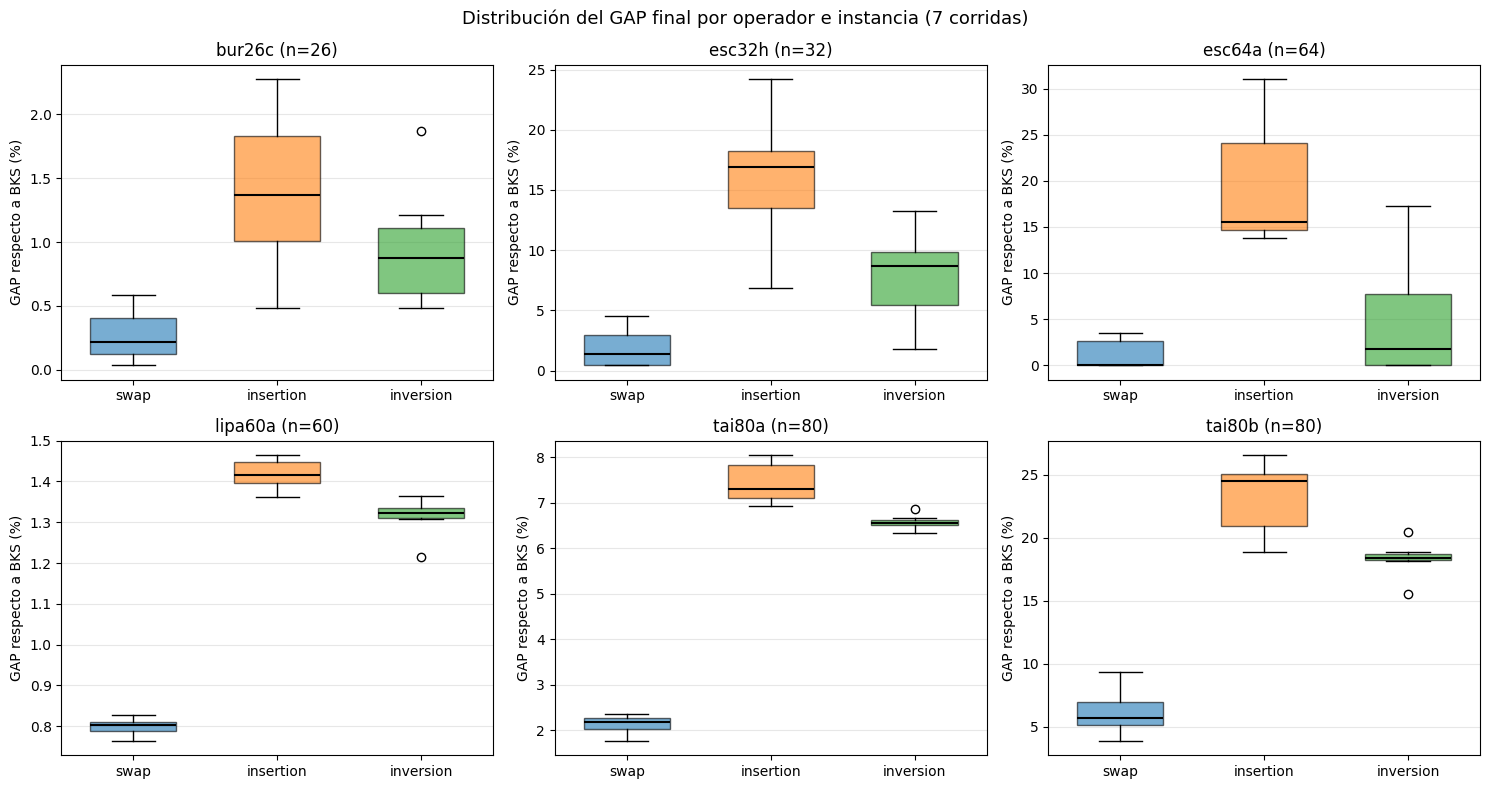

In [19]:
# results se carga desde los CSV en el Bloque 7; si no está en memoria, lo recargamos
if "results" not in dir():
    frames = [pd.read_csv(RESULTS_DIR / f"resultados_{op}.csv")
              for op in OPERATORS if (RESULTS_DIR / f"resultados_{op}.csv").exists()]
    results = pd.concat(frames, ignore_index=True)

FIGURES_DIR = RESULTS_DIR / "Figuras"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

operators = list(OPERATORS.keys())
COLORS = {"swap": "#1f77b4", "insertion": "#ff7f0e", "inversion": "#2ca02c"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, inst_name in zip(axes, INSTANCES):
    # GAP de las 7 corridas, por operador, para esta instancia
    data = [results[(results.instance == inst_name) & (results.operator == op)]["gap_percent"].values
            for op in operators]

    bp = ax.boxplot(data, labels=operators, patch_artist=True, widths=0.6,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, op in zip(bp["boxes"], operators):
        patch.set_facecolor(COLORS[op])
        patch.set_alpha(0.6)

    ax.set_title(f"{inst_name} (n={INSTANCES[inst_name]['size']})")
    ax.set_ylabel("GAP respecto a BKS (%)")
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Distribución del GAP final por operador e instancia (7 corridas)", fontsize=13)
fig.tight_layout()

out = FIGURES_DIR / "boxplots_gap.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"✓ Guardada: {out}")
plt.show()